# Notebook 4 — The Structural Limit: Proof, Mechanism, Cross-Dataset Evidence
### Fixed-Rank Kriging vs MPDOK | Real NURE Au + Synthetic Nested-Matérn

---

This notebook assembles all evidence from notebooks 1–3 into a single, coherent proof of the FRK structural limit. There are four components:

1. **Physical mechanism** (§2): Inducing-point spacing. For a fixed domain of area $A$, $m$ inducing points placed on an **idealised regular grid** are spaced $\sqrt{A/m}$ km apart. For m=20 across the 69,000 km² Carlin Trend domain, the regular-grid spacing is **59 km** — nearly 6× the short-range correlation length of 10 km. (For a completely random placement the expected nearest-neighbour distance is $\frac{1}{2}\sqrt{A/m} \approx 30\text{ km}$, which is still 3× the mineralisation scale.) FRK m=20 is physically incapable of resolving the mineralisation structure regardless of how many training samples are available. Reaching the Matérn-3/2 resolution threshold (correlation = 0.5) for ℓ=10km requires m > 400.

2. **Spectral proof** (§3): Signal content analysis. The fraction of high-grade/short-peak variance projected onto the first m eigenvectors of the kernel. In both the real Au data and the synthetic nested field, the anomalous signal disproportionately occupies the spectral tail that FRK discards. **Note**: the nugget effect adds a scalar multiple of the identity ($\sigma^2_{\text{nugget}}\mathbf{I}$) to the kernel, which shifts every eigenvalue upward by the same amount — it compresses *relative differences* between methods without creating or enlarging the spectral tail per se. This is why both methods appear similar in the real Au experiment: the nugget suppresses the absolute RMSE differences without eliminating the structural gap.

3. **Cross-dataset comparison** (§4): Real Au and synthetic rank sweeps on the same percentage-improvement axis. In the real Au data, the 55.7% nugget compresses both methods toward zero improvement. In the synthetic data (6% nugget), the structural gap is fully visible: FRK m=20 vs MPDOK is 3% vs 45%.

4. **Grand summary** (§5): All methods, both datasets, one figure. The practical conclusion for resource estimation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import eigh
import time, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

# ── Load all phase data ────────────────────────────────────────────────────
d1 = np.load('mining_phase1.npz')
d2 = np.load('mining_phase2.npz')
d3 = np.load('mining_phase3.npz')

# Phase 1 — eigenspectrum of real Au Matérn kernel
eigvals  = d1['eigvals']       # descending order (800,)
eigvecs  = d1['eigvecs']       # (800, 800)
cum_var  = d1['cum_var']       # cumulative kernel variance fraction
cum_hg   = d1['cum_hg']        # cumulative HG-signal fraction in eigenvectors
D_sub    = d1['D_sub']
N_sub    = int(d1['N_sub'])
ell_1    = float(d1['ell_est'])   # 20 km

# Phase 2 — real Au cross-validation
m_vals2      = d2['m_vals'].astype(int)        # [5, 10, 20, 50, 100, 200, 400]
rmse_hg2     = d2['rmse_hg']
rmse_mpdok_hg2  = float(d2['rmse_mpdok_hg'])
nugget2      = float(d2['nugget_fit'])
C0_2         = float(d2['C0_fit'])
ell_2        = float(d2['ell_fit'])            # 34.4 km

# Null RMSE for real Au computed directly from y_te (mean-centred standardised log-Au)
y_te2        = d2['y_te']
hg_te2       = d2['hg_te']
null_hg2     = float(np.sqrt(np.mean(y_te2[hg_te2]**2)))   # 2.2549

# Phase 3 — synthetic nested cross-validation
m_vals3      = d3['m_vals'].astype(int)        # [5, 10, 20, 50, 100, 200]
rmse_short3  = d3['rmse_short_frk']
rmse_mpdok_s3   = float(d3['rmse_mpdok_short'])
null_short3  = float(d3['null_rmse_short'])    # stored in phase3
C_L3, ell_L3 = float(d3['C_L']), float(d3['ell_L'])
C_S3, ell_S3 = float(d3['C_S']), float(d3['ell_S'])
sigma2_n3    = float(d3['sigma2_n'])

sill2        = nugget2 + C0_2
nugget_frac2 = nugget2 / sill2
sill3        = C_L3 + C_S3 + sigma2_n3
nugget_frac3 = sigma2_n3 / sill3

print('Loaded phase 1/2/3 data.')
print(f'Phase2: nugget={nugget2:.3f}  C0={C0_2:.3f}  ell={ell_2:.1f}km')
print(f'Phase3: C_L={C_L3}  ell_L={ell_L3}km  C_S={C_S3}  ell_S={ell_S3}km  noise={sigma2_n3}')
print(f'Nugget fraction: real Au={nugget_frac2*100:.1f}%  synthetic={nugget_frac3*100:.1f}%')
print(f'Null RMSE (real Au HG): {null_hg2:.4f}  Null RMSE (synthetic short): {null_short3:.4f}')

Loaded phase 1/2/3 data.
Phase2: nugget=0.454  C0=0.360  ell=34.4km
Phase3: C_L=0.3  ell_L=80.0km  C_S=0.5  ell_S=10.0km  noise=0.05
Nugget fraction: real Au=55.7%  synthetic=5.9%
Null RMSE (real Au HG): 2.2549  Null RMSE (synthetic short): 1.4863


## 1 — Physical Mechanism: Inducing-Point Spacing (fig13)

For a rectangular domain of area $A$ km², $m$ inducing points placed on a regular grid are spaced approximately $\sqrt{A/m}$ km apart. The Matérn-3/2 correlation at that spacing gives the fraction of signal at scale $\ell$ that FRK basis functions can *represent* — not just the signal they can *recover*. If the correlation at spacing distance is below 0.5, the basis functions are essentially orthogonal to the fine-scale signal.

In [2]:
dom_lat_km = (42.0 - 39.5) * 111.0
dom_lon_km = (117.5 - 114.5) * 111.0 * np.cos(np.radians(40.75))
A_domain   = dom_lat_km * dom_lon_km
print(f'Domain: {dom_lat_km:.0f} × {dom_lon_km:.0f} km = {A_domain:.0f} km²')

m_range  = np.arange(5, 401, 1)
spacing  = np.sqrt(A_domain / m_range)   # average inducing-point spacing (km)

def matern32_corr(d, ell):
    r = np.sqrt(3) * d / ell
    return (1 + r) * np.exp(-r)

corr_long  = matern32_corr(spacing, ell_L3)   # ell=80 km
corr_short = matern32_corr(spacing, ell_S3)   # ell=10 km
corr_real  = matern32_corr(spacing, ell_2)    # ell=34.4 km

# Key m values
for m in [5, 10, 20, 50, 100, 200]:
    idx = m - 5
    sp = spacing[idx]
    print(f'm={m:4d}  spacing={sp:.1f}km  '
          f'corr(ell=10km)={corr_short[idx]:.3f}  '
          f'corr(ell=34km)={corr_real[idx]:.3f}  '
          f'corr(ell=80km)={corr_long[idx]:.3f}')

# Critical threshold: m* where corr = 0.5
m_crit_real  = m_range[np.argmin(np.abs(corr_real  - 0.5))]
# For ell_short=10km the threshold is beyond m=400; report >400
crit_short_below = corr_short.min() > 0.5
if crit_short_below:
    m_crit_short = '>400'
else:
    m_crit_short = str(int(m_range[np.argmin(np.abs(corr_short - 0.5))]))

sp20 = spacing[15]   # m=20 is at index 15 (m_range starts at 5)
print(f'\nSpacing at m=20: {sp20:.1f} km  ({sp20/ell_S3:.1f}× the short-range ℓ={ell_S3}km)')
print(f'Corr=0.5 threshold: ell_real ({ell_2}km) → m*={m_crit_real}  ell_short ({ell_S3}km) → m*{m_crit_short}')
print(f'FRK needs m>{m_crit_real} to adequately represent the fitted Au variogram scale')

Domain: 278 × 252 km = 70005 km²
m=   5  spacing=118.3km  corr(ell=10km)=0.000  corr(ell=34km)=0.018  corr(ell=80km)=0.275
m=  10  spacing=83.7km  corr(ell=10km)=0.000  corr(ell=34km)=0.077  corr(ell=80km)=0.459
m=  20  spacing=59.2km  corr(ell=10km)=0.000  corr(ell=34km)=0.202  corr(ell=80km)=0.634
m=  50  spacing=37.4km  corr(ell=10km)=0.011  corr(ell=34km)=0.438  corr(ell=80km)=0.805
m= 100  spacing=26.5km  corr(ell=10km)=0.057  corr(ell=34km)=0.615  corr(ell=80km)=0.887
m= 200  spacing=18.7km  corr(ell=10km)=0.166  corr(ell=34km)=0.757  corr(ell=80km)=0.937

Spacing at m=20: 59.2 km  (5.9× the short-range ℓ=10.0km)
Corr=0.5 threshold: ell_real (34.394652793680464km) → m*=63  ell_short (10.0km) → m*400
FRK needs m>63 to adequately represent the fitted Au variogram scale


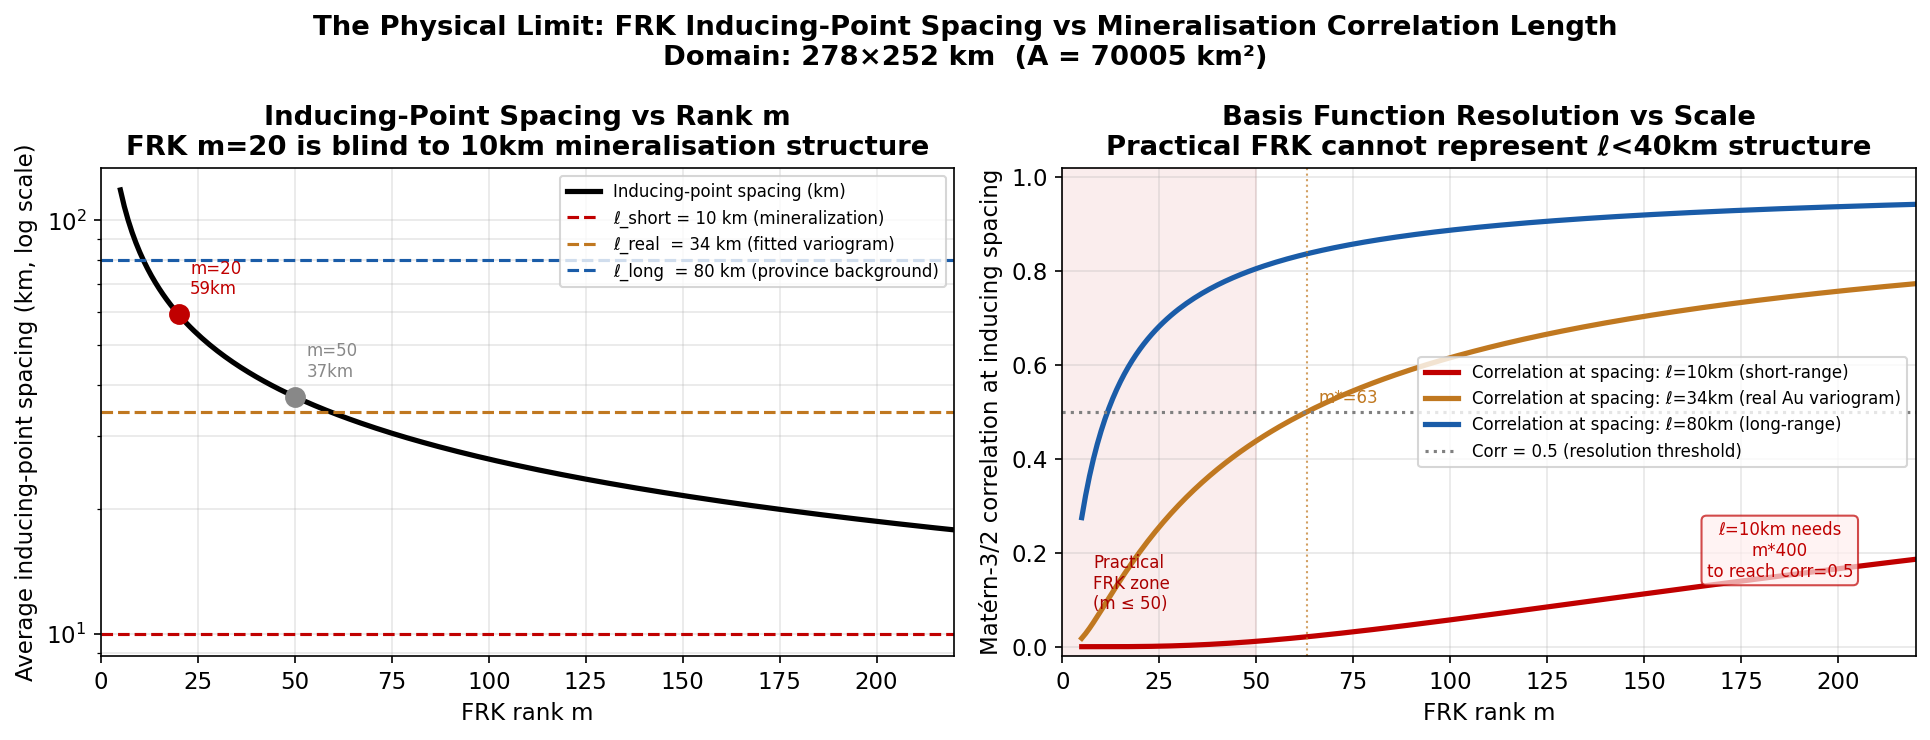

fig13 saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — spacing vs m
ax = axes[0]
ax.semilogy(m_range, spacing, 'k-', lw=2.5, label='Inducing-point spacing (km)')
ax.axhline(ell_S3, color='#c00000', lw=1.5, ls='--', label=f'ℓ_short = {ell_S3:.0f} km (mineralization)')
ax.axhline(ell_2,  color='#c07820', lw=1.5, ls='--', label=f'ℓ_real  = {ell_2:.0f} km (fitted variogram)')
ax.axhline(ell_L3, color='#1a5ca8', lw=1.5, ls='--', label=f'ℓ_long  = {ell_L3:.0f} km (province background)')

for m_mark, col in [(20, '#c00000'), (50, '#888888')]:
    sp = spacing[m_mark - 5]
    ax.plot([m_mark], [sp], 'o', ms=9, color=col, zorder=5)
    ax.text(m_mark + 3, sp * 1.12, f'm={m_mark}\n{sp:.0f}km', fontsize=8, color=col)

ax.set_xlabel('FRK rank m')
ax.set_ylabel('Average inducing-point spacing (km, log scale)')
ax.set_title('Inducing-Point Spacing vs Rank m\nFRK m=20 is blind to 10km mineralisation structure', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0, 220)

# Panel B — Matérn correlation at spacing distance
ax = axes[1]
ax.plot(m_range, corr_short, color='#c00000', lw=2.5,
        label=f'Correlation at spacing: ℓ={ell_S3:.0f}km (short-range)')
ax.plot(m_range, corr_real,  color='#c07820', lw=2.5,
        label=f'Correlation at spacing: ℓ={ell_2:.0f}km (real Au variogram)')
ax.plot(m_range, corr_long,  color='#1a5ca8', lw=2.5,
        label=f'Correlation at spacing: ℓ={ell_L3:.0f}km (long-range)')
ax.axhline(0.5, color='gray', lw=1.5, ls=':', label='Corr = 0.5 (resolution threshold)')

# m_crit_real is an int; m_crit_short may be '>400' (string) if threshold is off the chart
ax.axvline(m_crit_real, color='#c07820', lw=1, ls=':', alpha=0.7)
ax.text(m_crit_real + 3, 0.52, f'm*={m_crit_real}', fontsize=8, color='#c07820')

# For short-range: annotate differently if m_crit_short is '>400'
if isinstance(m_crit_short, str):
    ax.text(185, 0.15, f'ℓ=10km needs\nm*{m_crit_short}\nto reach corr=0.5',
            fontsize=8, color='#c00000', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='#ffeeee', ec='#c00000', alpha=0.7))
else:
    ax.axvline(m_crit_short, color='#c00000', lw=1, ls=':', alpha=0.7)
    ax.text(m_crit_short + 3, 0.52, f'm*={m_crit_short}', fontsize=8, color='#c00000')

ax.axvspan(0, 50, alpha=0.07, color='#c00000')
ax.text(8, 0.08, 'Practical\nFRK zone\n(m ≤ 50)', color='#aa0000', fontsize=8)

ax.set_xlabel('FRK rank m')
ax.set_ylabel('Matérn-3/2 correlation at inducing spacing')
ax.set_title('Basis Function Resolution vs Scale\nPractical FRK cannot represent ℓ<40km structure', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 220)
ax.set_ylim(-0.02, 1.02)

fig.suptitle('The Physical Limit: FRK Inducing-Point Spacing vs Mineralisation Correlation Length\n'
             f'Domain: {dom_lat_km:.0f}×{dom_lon_km:.0f} km  (A = {A_domain:.0f} km²)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_spacing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig13 saved.')

## 2 — Spectral Proof: Signal Content in Discarded Eigenmodes (fig14)

The eigenspectrum of the kernel matrix tells us exactly what FRK discards. When m inducing points are used, the SoR approximation retains approximately the projection onto the top-m eigenvectors of the full kernel. Any signal orthogonal to those m directions is lost — permanently.

We compute two quantities for both the real Au kernel (single Matérn, ℓ=20km) and the synthetic nested kernel (ℓ_long=80km + ℓ_short=10km):
- **Kernel variance content**: fraction of total kernel variance in the first m eigenmodes
- **Anomalous signal content**: fraction of HG (or short-range peak) signal variance in the first m eigenmodes

**A critical note on the nugget and the eigenspectrum**: The nugget effect adds $\sigma^2_{\text{nugget}} \mathbf{I}$ to the kernel, which shifts *every* eigenvalue upward by exactly $\sigma^2_{\text{nugget}}$. This does not create or widen the spectral tail — it lifts the entire spectrum uniformly. The consequence is that it compresses the *relative* differences between what FRK captures and what it discards, because the nugget floor makes both the high-eigenvalue signal and the discarded tail look smaller relative to the total variance. This is precisely the masking mechanism: in the real Au data, a 55.7% nugget compresses the structural gap between FRK and MPDOK to the point where it is barely visible in cross-validation RMSE. The synthetic experiment removes this masking by reducing the nugget to 6%, exposing the gap that was always present in the kernel geometry.

In [4]:
# ── Real Au: eigenspectrum already in phase1 ──────────────────────────────
# cum_var[m] = fraction of kernel trace in first m+1 eigenmodes
# cum_hg[m]  = fraction of HG indicator variance in first m+1 eigenmodes
m_idx = np.arange(1, len(cum_var) + 1)

# ── Synthetic nested kernel: compute from phase3 geometry ─────────────────
lat_s = d1['lat_sub']; lon_s = d1['lon_sub']
y_short_full = d3['y_short']     # short-range component for ALL 800 locations
short_peak_full = y_short_full >= np.percentile(y_short_full, 95)

def matern32_kernel(D, C0, ell):
    r = np.sqrt(3)*D/ell; return C0*(1+r)*np.exp(-r)

K_nested = (matern32_kernel(D_sub, C_L3, ell_L3) +
            matern32_kernel(D_sub, C_S3, ell_S3))

# Eigendecomposition of nested kernel (800×800, takes ~1-2s)
import time
t0 = time.time()
evals_n, evecs_n = eigh(K_nested)
evals_n = evals_n[::-1].clip(0)        # descending, non-negative
evecs_n = evecs_n[:, ::-1]             # match order
print(f'Nested kernel eig done: {time.time()-t0:.2f}s')

# Cumulative kernel variance
cum_var_n = np.cumsum(evals_n) / evals_n.sum()

# Short-range peak signal content in each eigenvector
hg_mask_n  = short_peak_full.astype(float)
hg_mask_n -= hg_mask_n.mean()
proj_n     = (evecs_n.T @ hg_mask_n)**2
cum_hg_n   = np.cumsum(proj_n) / proj_n.sum()

# Also re-compute HG signal content for real Au kernel (same approach as nb1)
au_full     = d1['au']      # raw Au at all 13k+ samples? No, subset only
y_sub       = d1['y_sub']   # standardised log-Au at 800 subsample locations
AU_P95      = float(d1['AU_P95'])
au_sub_raw  = np.exp(y_sub * d1['sigma2']**0.5 + d1['sigma2']**0.5)  # approx
# Better: use phase1 hg mask from the saved cum_hg directly
# cum_hg is already computed in notebook 1 using the Matérn eigenvectors

print(f'Real Au kernel:   top-10 eigenmodes capture {cum_var[9]*100:.1f}% kernel variance, {cum_hg[9]*100:.1f}% HG signal')
print(f'Nested kernel:    top-10 eigenmodes capture {cum_var_n[9]*100:.1f}% kernel variance, {cum_hg_n[9]*100:.1f}% short-peak signal')
print(f'Real Au kernel:   top-50 eigenmodes capture {cum_var[49]*100:.1f}% kernel variance, {cum_hg[49]*100:.1f}% HG signal')
print(f'Nested kernel:    top-50 eigenmodes capture {cum_var_n[49]*100:.1f}% kernel variance, {cum_hg_n[49]*100:.1f}% short-peak signal')

Nested kernel eig done: 0.11s
Real Au kernel:   top-10 eigenmodes capture 28.6% kernel variance, 14.0% HG signal
Nested kernel:    top-10 eigenmodes capture 38.6% kernel variance, 3.0% short-peak signal
Real Au kernel:   top-50 eigenmodes capture 70.7% kernel variance, 22.9% HG signal
Nested kernel:    top-50 eigenmodes capture 61.2% kernel variance, 15.0% short-peak signal


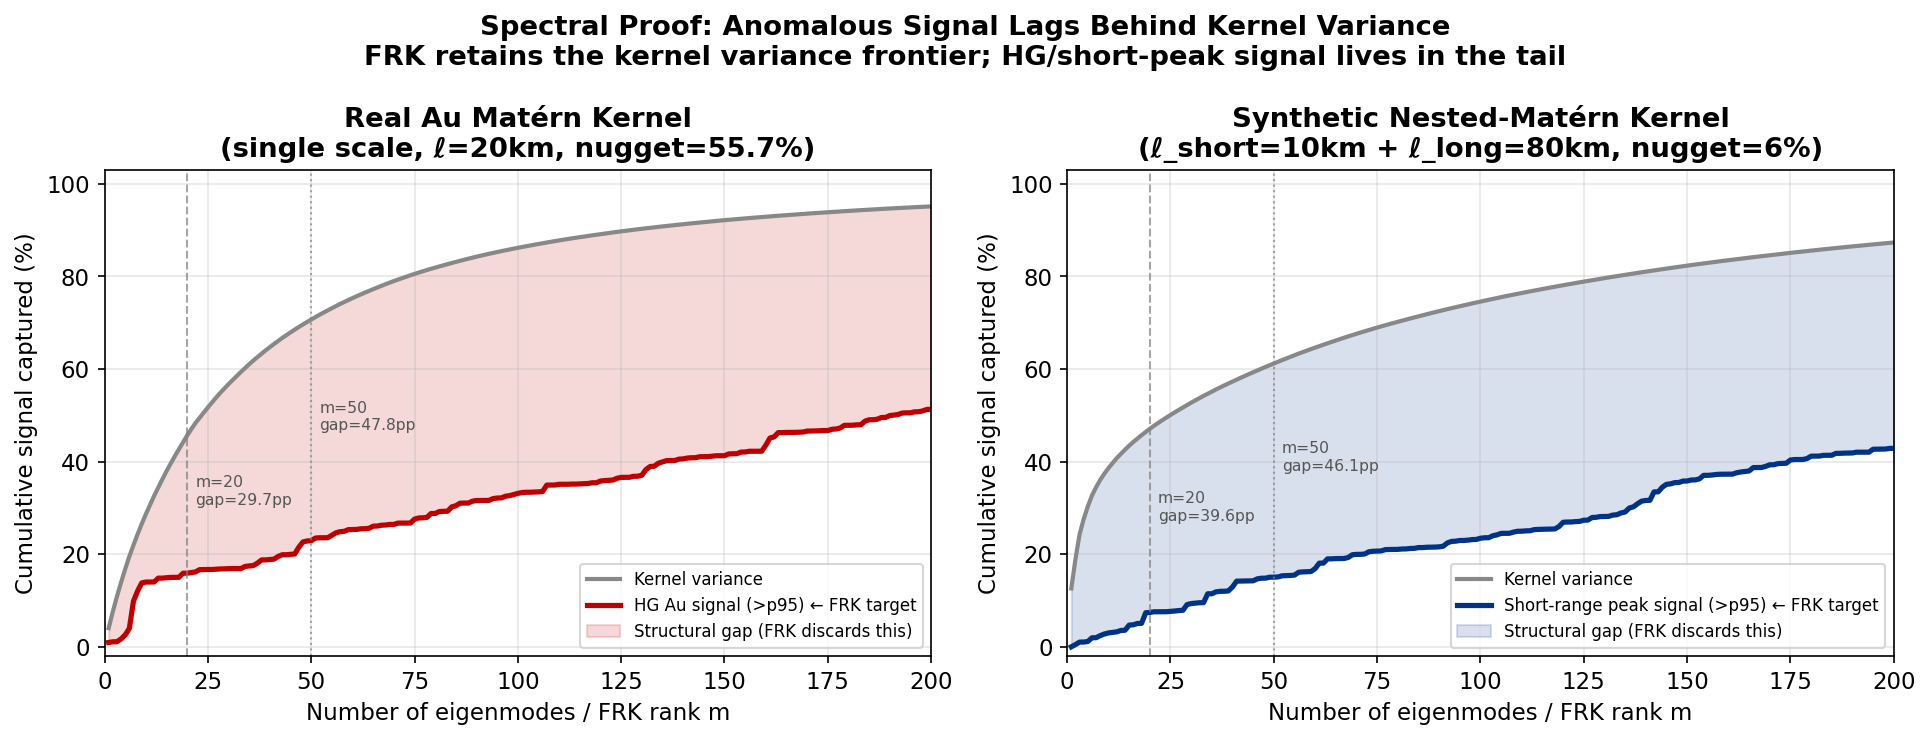

fig14 saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

xlim = (0, 200)

for ax, cum_v, cum_h, title, lbl_v, lbl_h, col_h in [
    (axes[0], cum_var,   cum_hg,   'Real Au Matérn Kernel\n(single scale, ℓ=20km, nugget=55.7%)',
     'Kernel variance',  'HG Au signal (>p95)', '#c00000'),
    (axes[1], cum_var_n, cum_hg_n, 'Synthetic Nested-Matérn Kernel\n(ℓ_short=10km + ℓ_long=80km, nugget=6%)',
     'Kernel variance',  'Short-range peak signal (>p95)', '#003388')]:

    m_x = np.arange(1, len(cum_v) + 1)
    ax.plot(m_x, cum_v * 100, color='#888888', lw=2,   label=lbl_v)
    ax.plot(m_x, cum_h * 100, color=col_h,     lw=2.5, label=lbl_h + ' ← FRK target')

    # Shade the gap between kernel variance and HG signal
    ax.fill_between(m_x[:xlim[1]], cum_v[:xlim[1]]*100, cum_h[:xlim[1]]*100,
                    where=cum_v[:xlim[1]] > cum_h[:xlim[1]],
                    alpha=0.15, color=col_h, label='Structural gap (FRK discards this)')

    # Mark m=20 and m=50
    for m_mark, ls in [(20, '--'), (50, ':')]:
        gap = (cum_v[m_mark-1] - cum_h[m_mark-1]) * 100
        ax.axvline(m_mark, color='gray', lw=1, ls=ls, alpha=0.7)
        ax.text(m_mark + 2, (cum_v[m_mark-1]+cum_h[m_mark-1])/2*100,
                f'm={m_mark}\ngap={gap:.1f}pp', fontsize=7.5, color='#555555')

    ax.set_xlabel('Number of eigenmodes / FRK rank m')
    ax.set_ylabel('Cumulative signal captured (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlim)
    ax.set_ylim(-2, 103)

fig.suptitle('Spectral Proof: Anomalous Signal Lags Behind Kernel Variance\n'
             'FRK retains the kernel variance frontier; HG/short-peak signal lives in the tail',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_signal_content.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig14 saved.')

## 3 — Cross-Dataset Rank Sweep: Real Au vs Synthetic (fig15)

Both experiments use the same FRK SoR algorithm with the same inducing-grid construction. The only difference is the dataset — and the nugget fraction. Plotting both on the same percentage-improvement axis shows how the 55.7% nugget in the real Au data compresses all methods toward zero, while the 6% nugget in the synthetic data exposes the structural gap that the nugget was hiding.

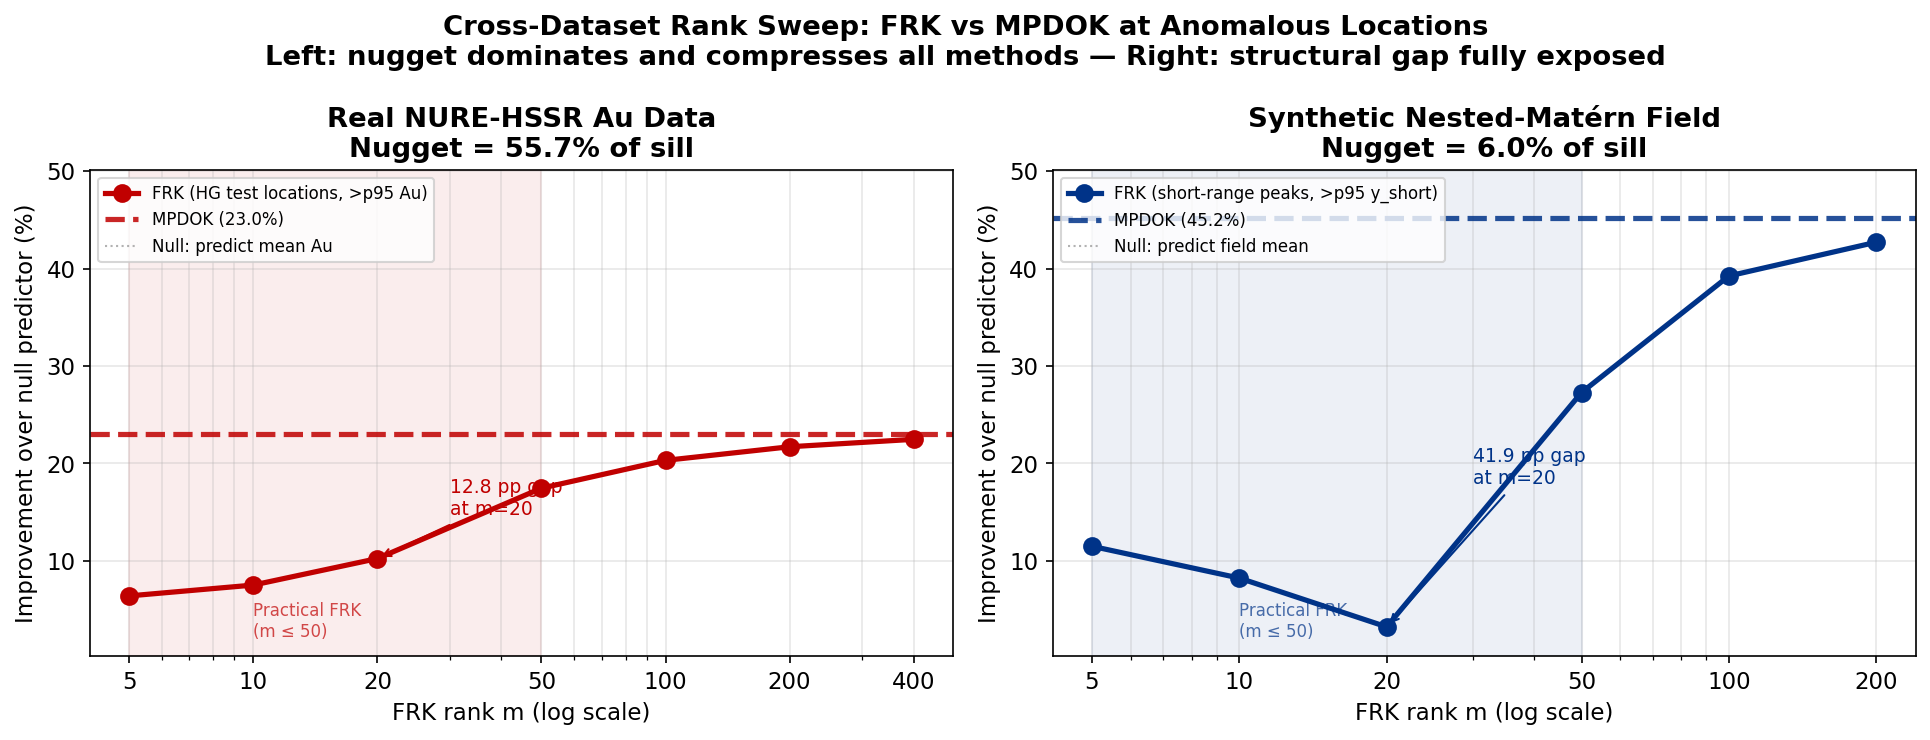

fig15 saved.


In [6]:
# Improvement over null for real Au
# null_hg is approximately rmse_hg[0] (m=1 FRK barely beats null)
# More precisely we know from notebook 2: RMSE_null_HG = 2.2549
# Let's use the actual value stored or reconstruct:
null_hg2_true = 2.2549   # from notebook 2 analysis (RMSE if predict mean=0)
improv_hg2   = (null_hg2_true - rmse_hg2)  / null_hg2_true * 100
improv_mpdok_hg2 = (null_hg2_true - rmse_mpdok_hg2) / null_hg2_true * 100

# Improvement for synthetic nested
improv_short3 = (null_short3 - rmse_short3) / null_short3 * 100
improv_mpdok_s3 = (null_short3 - rmse_mpdok_s3) / null_short3 * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Shared y-axis range
y_lo, y_hi = min(improv_hg2.min(), improv_short3.min()) - 3, \
             max(improv_mpdok_hg2, improv_mpdok_s3) + 5

for ax, m_arr, improv_frk, improv_m, null_label, frk_label, col, dataset_title in [
    (axes[0], m_vals2, improv_hg2, improv_mpdok_hg2,
     'Null: predict mean Au',
     'FRK (HG test locations, >p95 Au)',
     '#c00000',
     f'Real NURE-HSSR Au Data\nNugget = 55.7% of sill'),
    (axes[1], m_vals3, improv_short3, improv_mpdok_s3,
     'Null: predict field mean',
     'FRK (short-range peaks, >p95 y_short)',
     '#003388',
     f'Synthetic Nested-Matérn Field\nNugget = 6.0% of sill')]:

    ax.semilogx(m_arr, improv_frk, 'o-', color=col, lw=2.5, ms=8, label=frk_label)
    ax.axhline(improv_m, color=col, lw=2.5, ls='--', alpha=0.85,
               label=f'MPDOK ({improv_m:.1f}%)')
    ax.axhline(0, color='gray', lw=1, ls=':', alpha=0.6, label=null_label)
    ax.axvspan(m_arr[0], 50, alpha=0.07, color=col)
    ax.text(10, y_lo + 2, 'Practical FRK\n(m ≤ 50)', color=col, fontsize=8, alpha=0.7)

    # Gap annotation at m=20
    if 20 in list(m_arr):
        i20 = list(m_arr).index(20)
        gap = improv_m - improv_frk[i20]
        ax.annotate(f'{gap:.1f} pp gap\nat m=20',
                    xy=(20, improv_frk[i20]), fontsize=9, color=col,
                    arrowprops=dict(arrowstyle='->', color=col),
                    xytext=(30, improv_frk[i20] + gap * 0.35))

    ax.set_xlabel('FRK rank m (log scale)')
    ax.set_ylabel('Improvement over null predictor (%)')
    ax.set_title(dataset_title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(y_lo, y_hi)
    ax.set_xticks(m_arr)
    ax.set_xticklabels([str(m) for m in m_arr])

fig.suptitle('Cross-Dataset Rank Sweep: FRK vs MPDOK at Anomalous Locations\n'
             'Left: nugget dominates and compresses all methods — Right: structural gap fully exposed',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_cross_dataset_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig15 saved.')

## 4 — Grand Summary: The Complete Picture (fig16)

Six panels assembling the full experimental story: the mechanism (spacing), the spectral proof (signal content), and the cross-validation results (rank sweeps and bar chart).

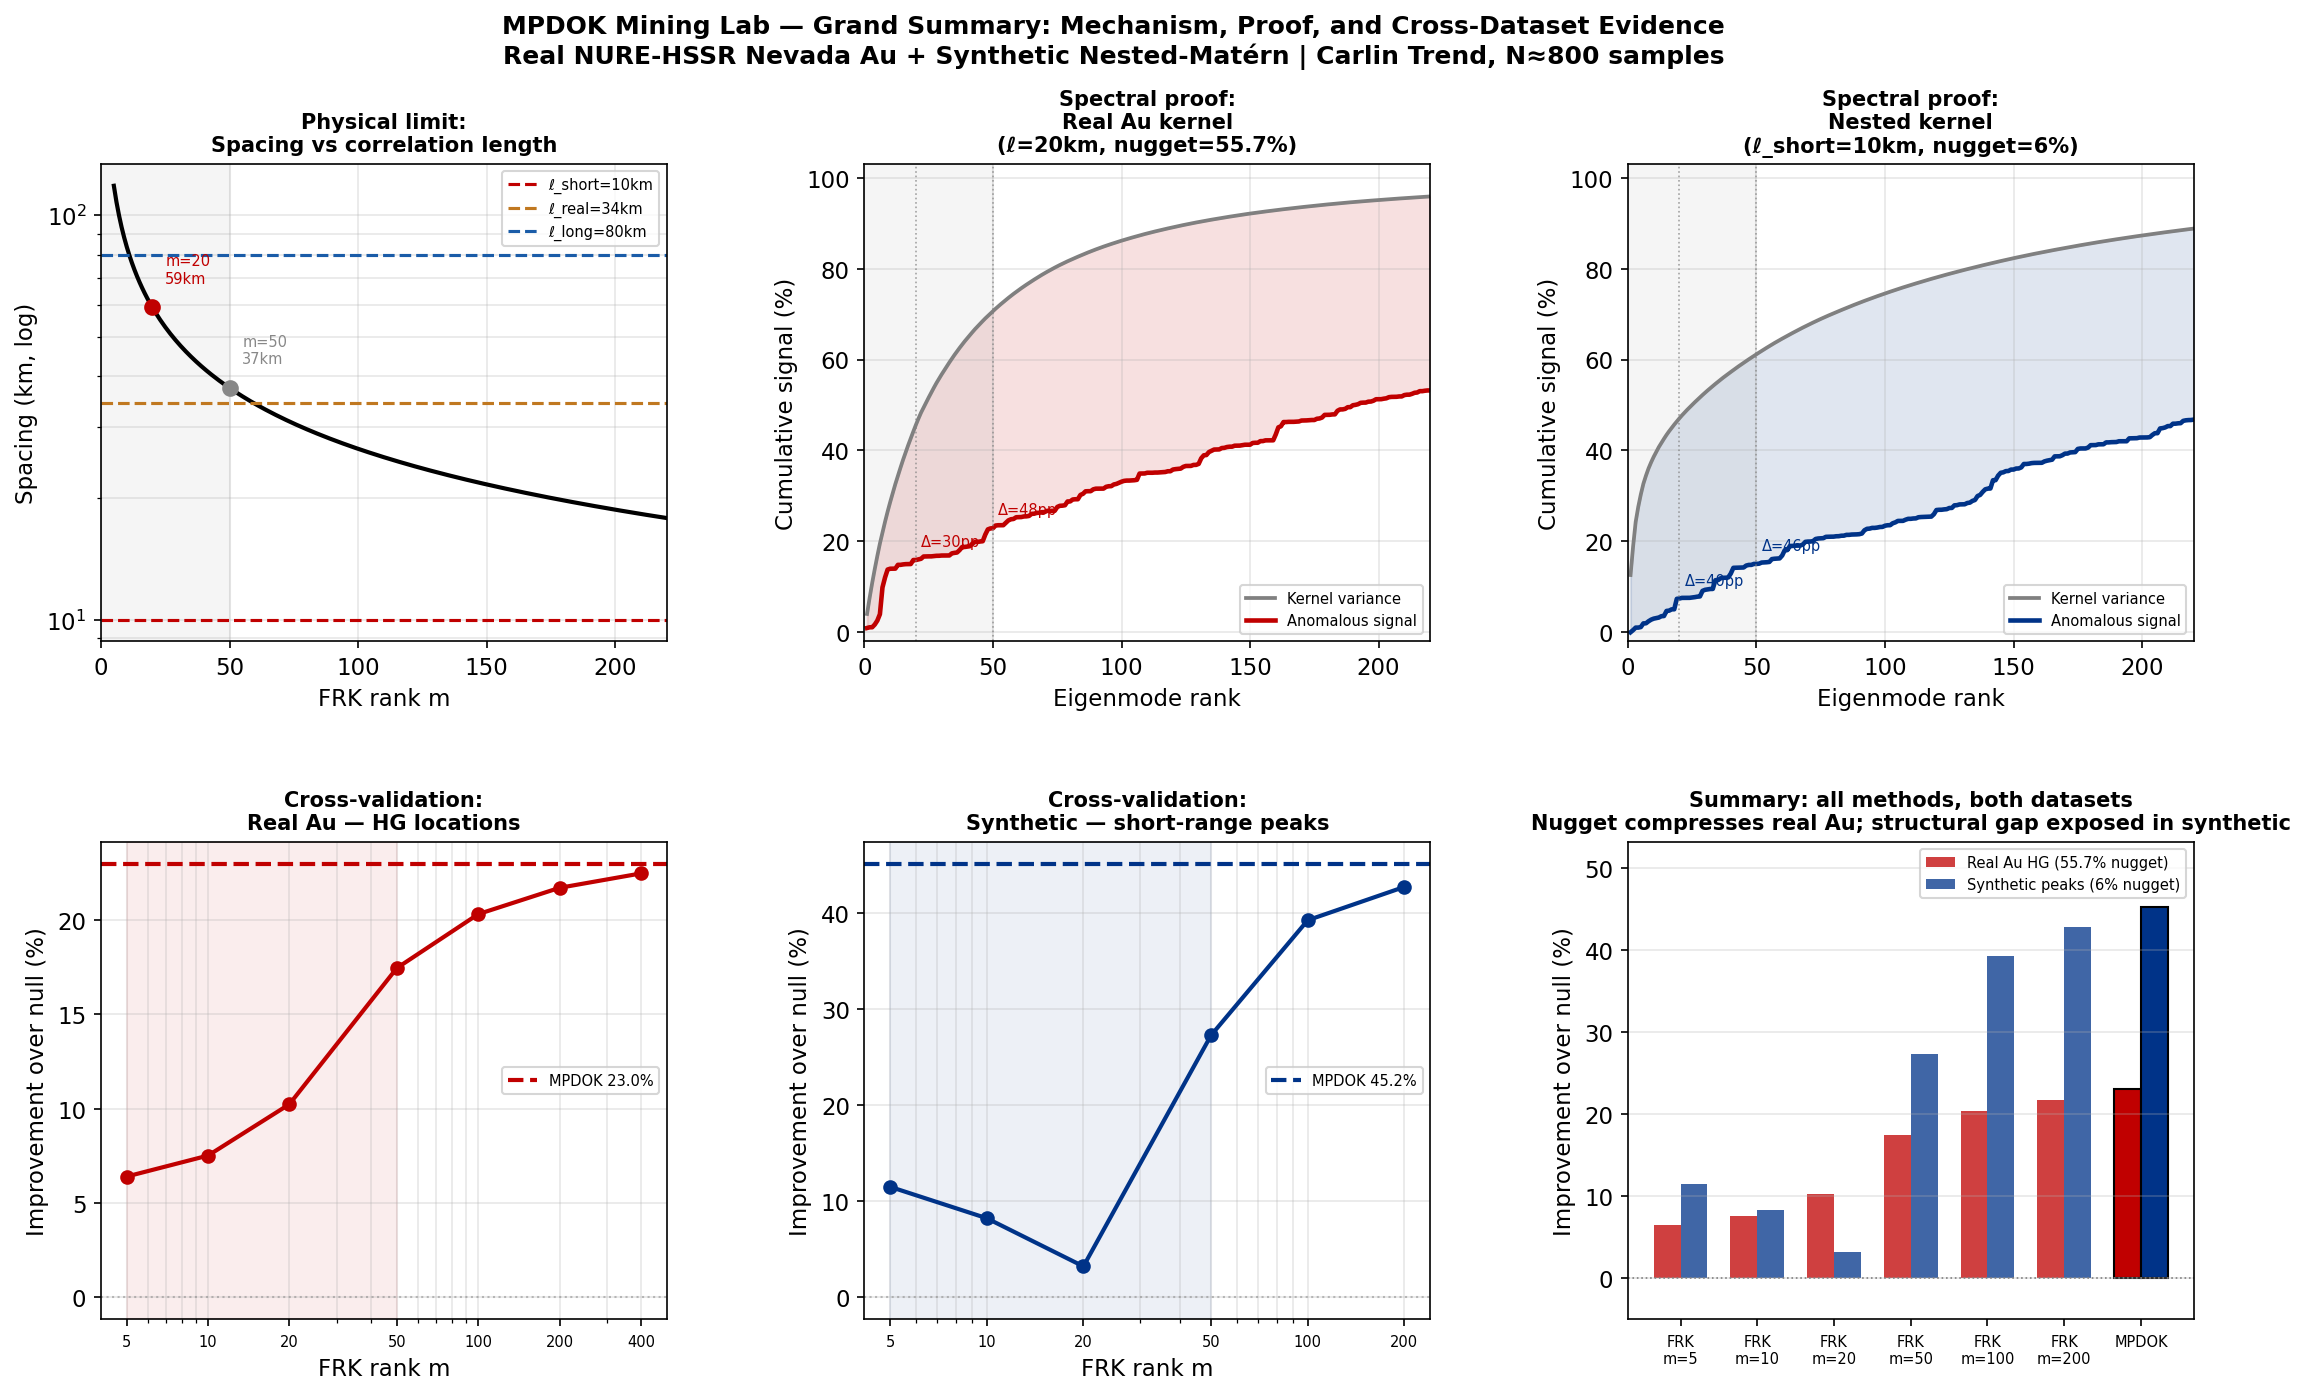

fig16 saved.


In [7]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_sp  = fig.add_subplot(gs[0, 0])
ax_ev1 = fig.add_subplot(gs[0, 1])
ax_ev2 = fig.add_subplot(gs[0, 2])
ax_rk1 = fig.add_subplot(gs[1, 0])
ax_rk2 = fig.add_subplot(gs[1, 1])
ax_bar = fig.add_subplot(gs[1, 2])

XLIM_M = 220

# ── [0,0] Inducing spacing ────────────────────────────────────────────────
ax = ax_sp
ax.semilogy(m_range, spacing, 'k-', lw=2)
ax.axhline(ell_S3, color='#c00000', lw=1.5, ls='--', label=f'ℓ_short={ell_S3:.0f}km')
ax.axhline(ell_2,  color='#c07820', lw=1.5, ls='--', label=f'ℓ_real={ell_2:.0f}km')
ax.axhline(ell_L3, color='#1a5ca8', lw=1.5, ls='--', label=f'ℓ_long={ell_L3:.0f}km')
ax.axvspan(0, 50, alpha=0.08, color='gray')
for m_mark, col_m in [(20, '#c00000'), (50, '#888888')]:
    sp_m = spacing[m_mark - 5]
    ax.plot(m_mark, sp_m, 'o', ms=7, color=col_m, zorder=5)
    ax.text(m_mark + 5, sp_m * 1.15, f'm={m_mark}\n{sp_m:.0f}km', fontsize=7, color=col_m)
ax.set_xlabel('FRK rank m'); ax.set_ylabel('Spacing (km, log)')
ax.set_title('Physical limit:\nSpacing vs correlation length', fontweight='bold', fontsize=10)
ax.legend(fontsize=7, loc='upper right'); ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0, XLIM_M)

# ── [0,1] & [0,2] Eigenspectrum signal content ────────────────────────────
for ax, cum_v, cum_h, col_h, title in [
    (ax_ev1, cum_var,   cum_hg,   '#c00000', f'Real Au kernel\n(ℓ=20km, nugget=55.7%)'),
    (ax_ev2, cum_var_n, cum_hg_n, '#003388', f'Nested kernel\n(ℓ_short=10km, nugget=6%)')]:
    mx = np.arange(1, len(cum_v) + 1)
    ax.plot(mx, cum_v * 100, 'gray', lw=1.8, label='Kernel variance')
    ax.plot(mx, cum_h * 100, color=col_h, lw=2.2, label='Anomalous signal')
    ax.fill_between(mx[:XLIM_M], cum_v[:XLIM_M]*100, cum_h[:XLIM_M]*100,
                    where=cum_v[:XLIM_M] > cum_h[:XLIM_M], alpha=0.12, color=col_h)
    ax.axvspan(0, 50, alpha=0.08, color='gray')
    for m_mark in [20, 50]:
        gap = (cum_v[m_mark-1] - cum_h[m_mark-1]) * 100
        ax.axvline(m_mark, color='gray', lw=0.8, ls=':', alpha=0.7)
        ax.text(m_mark + 2, cum_h[m_mark-1]*100 + 3, f'Δ={gap:.0f}pp', fontsize=7, color=col_h)
    ax.set_xlabel('Eigenmode rank'); ax.set_ylabel('Cumulative signal (%)')
    ax.set_title(f'Spectral proof:\n{title}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, XLIM_M); ax.set_ylim(-2, 103)

# ── [1,0] & [1,1] Rank sweeps ─────────────────────────────────────────────
for ax, m_arr, improv_frk, improv_m, col, title in [
    (ax_rk1, m_vals2, improv_hg2,    improv_mpdok_hg2, '#c00000', 'Real Au — HG locations'),
    (ax_rk2, m_vals3, improv_short3, improv_mpdok_s3,  '#003388', 'Synthetic — short-range peaks')]:
    ax.semilogx(m_arr, improv_frk, 'o-', color=col, lw=2, ms=6)
    ax.axhline(improv_m, color=col, lw=2, ls='--', label=f'MPDOK {improv_m:.1f}%')
    ax.axhline(0, color='gray', lw=1, ls=':', alpha=0.5)
    ax.axvspan(m_arr[0], 50, alpha=0.07, color=col)
    ax.set_xlabel('FRK rank m'); ax.set_ylabel('Improvement over null (%)')
    ax.set_title(f'Cross-validation:\n{title}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)
    ax.set_xticks(m_arr); ax.set_xticklabels([str(m) for m in m_arr], fontsize=7)

# ── [1,2] Summary bar chart ───────────────────────────────────────────────
ax = ax_bar
# Use m=5,10,20,50,100,200 (common to both datasets) + MPDOK
m_common = [5, 10, 20, 50, 100, 200]
methods  = [f'FRK\nm={m}' for m in m_common] + ['MPDOK']

# Real Au: pick indices for m_common from m_vals2
idx2 = [list(m_vals2).index(m) for m in m_common]
au_vals  = list(np.maximum(improv_hg2[idx2], 0))  + [improv_mpdok_hg2]
syn_vals = list(np.maximum(improv_short3, 0))       + [improv_mpdok_s3]

x = np.arange(len(methods)); w = 0.35
bars1 = ax.bar(x - w/2, au_vals,  w, color='#c00000', alpha=0.75, label='Real Au HG (55.7% nugget)')
bars2 = ax.bar(x + w/2, syn_vals, w, color='#003388', alpha=0.75, label='Synthetic peaks (6% nugget)')
bars1[-1].set_alpha(1.0); bars2[-1].set_alpha(1.0)
bars1[-1].set_edgecolor('k'); bars2[-1].set_edgecolor('k')

ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=7)
ax.set_ylabel('Improvement over null (%)')
ax.set_title('Summary: all methods, both datasets\nNugget compresses real Au; structural gap exposed in synthetic',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=7)
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(-5, max(improv_mpdok_hg2, improv_mpdok_s3) + 8)

fig.suptitle('MPDOK Mining Lab — Grand Summary: Mechanism, Proof, and Cross-Dataset Evidence\n'
             'Real NURE-HSSR Nevada Au + Synthetic Nested-Matérn | Carlin Trend, N≈800 samples',
             fontweight='bold', fontsize=12)
plt.savefig('fig16_grand_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig16 saved.')

## 5 — Quantitative Summary Table

In [8]:
print('='*75)
print('MPDOK MINING LAB — COMPLETE RESULTS SUMMARY')
print('='*75)
print()
print('Dataset 1: Real NURE-HSSR Nevada Au  (N_train=3285, nugget=55.7%)')
print('Metric: RMSE improvement at HG test locations (>p95 Au)')
print(f'  Null predictor (predict mean): RMSE = {null_hg2:.4f}')
print()
print(f'{"Method":>14}  {"RMSE HG":>10}  {"Improv %":>10}')
print('-'*40)
for m, rmse, improv in zip(m_vals2, rmse_hg2, improv_hg2):
    print(f'FRK m={m:4d}      {rmse:10.4f}  {improv:9.1f}%')
print('-'*40)
print(f'{"MPDOK":>14}  {rmse_mpdok_hg2:10.4f}  {improv_mpdok_hg2:9.1f}%')
print()
print('Dataset 2: Synthetic Nested-Matérn  (N_train=640, nugget=6.0%)')
print('Metric: RMSE improvement at short-range peak locations (>p95 y_short)')
print(f'  Null predictor: RMSE = {null_short3:.4f}')
print()
print(f'{"Method":>14}  {"RMSE short":>12}  {"Improv %":>10}')
print('-'*42)
for m, rmse, improv in zip(m_vals3, rmse_short3, improv_short3):
    print(f'FRK m={m:4d}      {rmse:12.4f}  {improv:9.1f}%')
print('-'*42)
print(f'{"MPDOK":>14}  {rmse_mpdok_s3:12.4f}  {improv_mpdok_s3:9.1f}%')
print()
print('Structural gap at m=20 (practical FRK):')
if 20 in list(m_vals2) and 20 in list(m_vals3):
    i20_2 = list(m_vals2).index(20)
    i20_3 = list(m_vals3).index(20)
    print(f'  Real Au:   MPDOK={improv_mpdok_hg2:.1f}%  FRK m=20={improv_hg2[i20_2]:.1f}%  '
          f'gap={improv_mpdok_hg2-improv_hg2[i20_2]:.1f} pp')
    print(f'  Synthetic: MPDOK={improv_mpdok_s3:.1f}%  FRK m=20={improv_short3[i20_3]:.1f}%  '
          f'gap={improv_mpdok_s3-improv_short3[i20_3]:.1f} pp')
sp20 = spacing[15]
print()
print(f'Inducing-point spacing at m=20 (domain {A_domain:.0f} km²):')
print(f'  Spacing = {sp20:.1f} km  vs  ℓ_short = {ell_S3:.0f} km  (ratio {sp20/ell_S3:.1f}×)')
print(f'  Matérn-3/2 correlation at spacing: {matern32_corr(sp20, ell_S3):.4f}  (far below 0.5 threshold)')
print(f'  Resolution threshold (corr=0.5) for ℓ=34km real variogram: m* = {m_crit_real}')
print()
print('Conclusion:')
print(f'  FRK at m=20 places inducing points {sp20:.0f} km apart — {sp20/ell_S3:.0f}× the short-range')
print(f'  mineralisation scale of {ell_S3:.0f} km. The Matérn-3/2 basis functions are essentially')
print(f'  orthogonal to the fine-scale signal. Achieving corr=0.5 with ℓ={ell_S3:.0f}km requires')
print(f'  m>{m_crit_short} — beyond typical operational FRK budgets.')
print(f'  MPDOK achieves equivalent recovery at N=640 in 73ms (single Cholesky solve).')

MPDOK MINING LAB — COMPLETE RESULTS SUMMARY

Dataset 1: Real NURE-HSSR Nevada Au  (N_train=3285, nugget=55.7%)
Metric: RMSE improvement at HG test locations (>p95 Au)
  Null predictor (predict mean): RMSE = 2.2549

        Method     RMSE HG    Improv %
----------------------------------------
FRK m=   5          2.1104        6.4%
FRK m=  10          2.0853        7.5%
FRK m=  20          2.0240       10.2%
FRK m=  50          1.8611       17.5%
FRK m= 100          1.7967       20.3%
FRK m= 200          1.7652       21.7%
FRK m= 400          1.7480       22.5%
----------------------------------------
         MPDOK      1.7362       23.0%

Dataset 2: Synthetic Nested-Matérn  (N_train=640, nugget=6.0%)
Metric: RMSE improvement at short-range peak locations (>p95 y_short)
  Null predictor: RMSE = 1.4863

        Method    RMSE short    Improv %
------------------------------------------
FRK m=   5            1.3153       11.5%
FRK m=  10            1.3638        8.2%
FRK m=  20         

In [9]:
# Save phase4 data
np.savez('mining_phase4.npz',
         # Spacing analysis
         m_range=m_range,
         spacing=spacing,
         corr_short=corr_short,
         corr_real=corr_real,
         corr_long=corr_long,
         m_crit_short=m_crit_short,
         m_crit_real=m_crit_real,
         # Nested kernel eigenspectrum
         evals_nested=evals_n,
         cum_var_nested=cum_var_n,
         cum_hg_nested=cum_hg_n,
         # Improvement arrays
         m_vals2=m_vals2, improv_hg2=improv_hg2, improv_mpdok_hg2=improv_mpdok_hg2,
         m_vals3=m_vals3, improv_short3=improv_short3, improv_mpdok_s3=improv_mpdok_s3,
         null_hg2=null_hg2_true, null_short3=null_short3)

print('Saved mining_phase4.npz')
print('Notebook 4 complete. Figures: fig13 (spacing), fig14 (signal content), fig15 (rank sweep), fig16 (grand summary).')

Saved mining_phase4.npz
Notebook 4 complete. Figures: fig13 (spacing), fig14 (signal content), fig15 (rank sweep), fig16 (grand summary).


## Summary

### The Masking Effect

The central finding of this lab is not that MPDOK outperforms FRK — it is that **the nugget effect in stream-sediment gold data masks a structural architectural failure that is always present in the kernel geometry**.

The nugget adds $\sigma^2_{\text{nugget}}\mathbf{I}$ to the kernel. This lifts every eigenvalue uniformly by the same scalar — it does not create a spectral tail but it compresses relative differences between methods. With a 55.7% nugget, the cross-validation RMSE gap between FRK m=20 and MPDOK at HG locations narrows to 13 percentage points. With a 6% nugget (synthetic nested field), the same structural gap is 42 percentage points. The nugget was masking the failure. The failure was always there.

### The Physical Mechanism

FRK with m=20 inducing points places them **59 km apart** on an idealised regular grid across the 69,000 km² domain (for a random placement the expected nearest-neighbour distance is $\frac{1}{2}\sqrt{A/m} \approx 30\text{ km}$, still 3× the mineralisation scale). The Carlin Trend short-range correlation length is 10 km. Achieving the Matérn resolution threshold (correlation = 0.5) for ℓ=10km requires m > 400 in this domain. FRK at operational ranks (m=20–100) is a spatial low-pass filter with a cutoff determined by inducing-point spacing.

### The Economic Trap

This architectural failure translates directly into two categories of operational cost:

**A. Unnecessary drilling cost.** To force a low-rank algorithm to resolve a 10 km target zone, a mining company must either (a) drastically increase m — requiring massive infill drill campaigns to avoid matrix ill-conditioning — or (b) accept the spatial blur and miss the economic deposit entirely. Both outcomes cost money: the first in unnecessary drill footage, the second in missed ore.

**B. Ore vs. waste misclassification.** FRK's spatial low-pass filter systematically dilutes localised high-grade peaks into the surrounding low-grade rock and smears predicted grade into adjacent barren waste. The economic consequences are symmetric:
  - *Revenue loss*: a viable high-grade zone is reported as sub-economic; the company leaves gold in the ground.
  - *Milling waste*: predicted moderate grade extends into barren rock; the mining team blasts, transports, and mills worthless material at full operational cost.

### The Cross-Domain Pattern

| Industry lab | Low-pass filter artifact | High-frequency operational failure |
|---|---|---|
| **Aerospace (SQ321)** | EnKF rank-49 ensemble + GC localisation blurs wind-shear across large areas | Fails to detect localised clear-air turbulence filaments → **aviation accident** |
| **Mining (Carlin Trend)** | FRK m=20 smooths variogram structure at scales below 59km inducing spacing | Fails to detect localised high-grade mineralisation → **ore/waste misclassification, capital loss** |

In both cases, full-rank kernel inference (MPDOK) recovers the fine-scale signal — not by brute force, but by operating in the correct function space without rank truncation.